In [1]:
import sys
print(sys.executable)

d:\AgriVision-AI\.venv\Scripts\python.exe


In [2]:
import numpy
import scipy
import sklearn

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.5.2
SciPy: 1.18.0
Scikit-learn: 1.9.0


In [3]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest import successful!")

Random Forest import successful!


In [4]:
from sklearn.ensemble import RandomForestClassifier
print("Random Forest OK")

Random Forest OK


In [5]:
from pathlib import Path
import numpy as np
from PIL import Image

IMG_SIZE = (64, 64)

train_dir = Path("../data/processed/train")
val_dir = Path("../data/processed/validation")
test_dir = Path("../data/processed/test")

class_names = [
    "brown_rust",
    "healthy",
    "yellow_rust"
]

def load_images(directory):
    X = []
    y = []

    for label, class_name in enumerate(class_names):
        class_dir = directory / class_name

        for image_path in class_dir.glob("*.jpg"):
            image = Image.open(image_path).convert("RGB")
            image = image.resize(IMG_SIZE)

            image_array = np.asarray(
                image,
                dtype=np.float32
            ) / 255.0

            X.append(image_array.flatten())
            y.append(label)

    return np.array(X), np.array(y)


X_train, y_train = load_images(train_dir)
X_val, y_val = load_images(val_dir)
X_test, y_test = load_images(test_dir)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (2058, 12288)
Validation: (440, 12288)
Test: (444, 12288)


In [7]:
from sklearn.metrics import accuracy_score, classification_report

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

val_predictions = rf_model.predict(X_val)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, val_predictions)
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        val_predictions,
        target_names=class_names
    )
)

Validation Accuracy: 0.8136363636363636

Classification Report:
              precision    recall  f1-score   support

  brown_rust       0.88      0.73      0.79       135
     healthy       0.81      0.91      0.86       167
 yellow_rust       0.77      0.78      0.78       138

    accuracy                           0.81       440
   macro avg       0.82      0.81      0.81       440
weighted avg       0.82      0.81      0.81       440



In [9]:
from sklearn.metrics import accuracy_score, classification_report

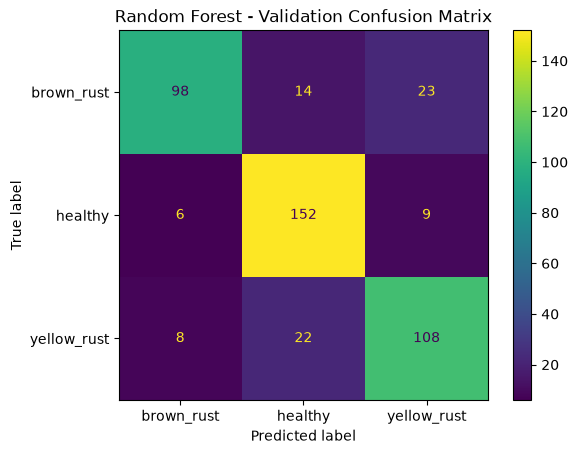

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, val_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

In [12]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.1


In [14]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=class_names,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=class_names,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=class_names,
    shuffle=False
)

print("Datasets loaded successfully.")

Found 2058 files belonging to 3 classes.
Found 440 files belonging to 3 classes.
Found 444 files belonging to 3 classes.
Datasets loaded successfully.


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [16]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "../models/best_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


d:\AgriVision-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 225ms/step - accuracy: 0.6720 - loss: 0.7146 - val_accuracy: 0.8136 - val_loss: 0.5933
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.8154 - loss: 0.4490 - val_accuracy: 0.7773 - val_loss: 0.8745
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 273ms/step - accuracy: 0.8844 - loss: 0.3182 - val_accuracy: 0.9023 - val_loss: 0.3303
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.8960 - loss: 0.2986 - val_accuracy: 0.8477 - val_loss: 0.5947
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.9159 - loss: 0.2376 - val_accuracy: 0.8614 - val_loss: 0.5494
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - accuracy: 0.9213 - loss: 0.2144 - val_accuracy: 0.8409 - val_loss: 0.9626
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 259ms/step - accuracy: 0.9203 - loss: 0.2063 - val_accuracy: 0.9114 - val_loss: 0.5213
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.9310 - loss: 0.2104 - val_accuracy: 0.902

In [19]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [20]:
best_val_accuracy = max(history.history["val_accuracy"])

print("Best Validation Accuracy:", best_val_accuracy)
print(
    "Best Epoch:",
    history.history["val_accuracy"].index(best_val_accuracy) + 1
)

Best Validation Accuracy: 0.9113636612892151
Best Epoch: 7


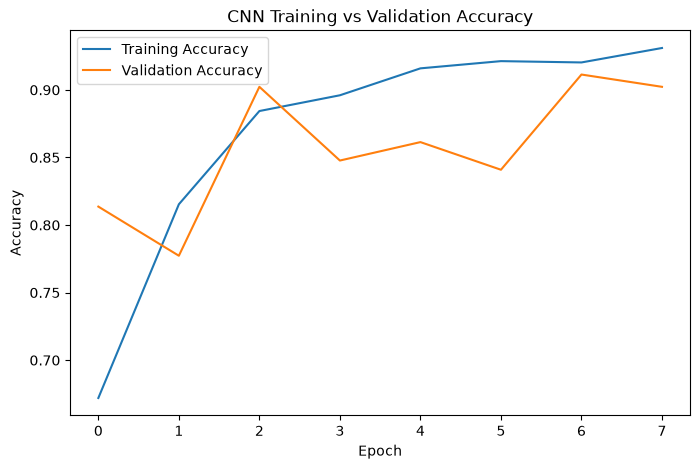

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

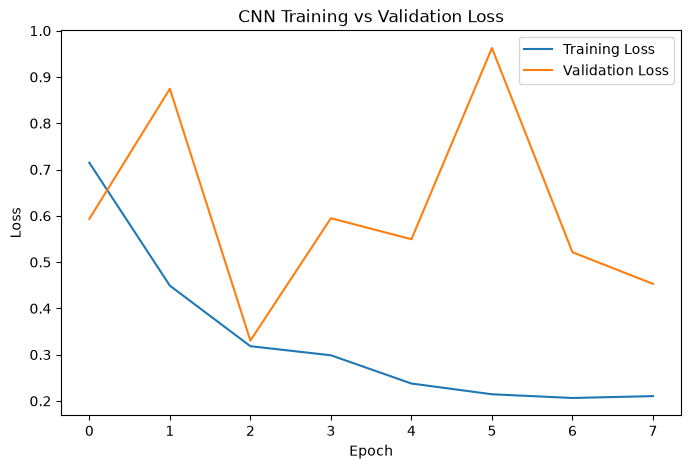

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9054 - loss: 0.3105
Test Loss: 0.3105424642562866
Test Accuracy: 0.9054054021835327


In [24]:
import numpy as np
from sklearn.metrics import classification_report

y_test_true = np.concatenate([
    y.numpy() for x, y in test_ds
])

y_test_pred = np.argmax(
    model.predict(test_ds),
    axis=1
)

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=class_names
    )
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
              precision    recall  f1-score   support

  brown_rust       0.95      0.88      0.91       136
     healthy       0.90      0.97      0.93       168
 yellow_rust       0.88      0.86      0.87       140

    accuracy                           0.91       444
   macro avg       0.91      0.90      0.90       444
weighted avg       0.91      0.91      0.90       444



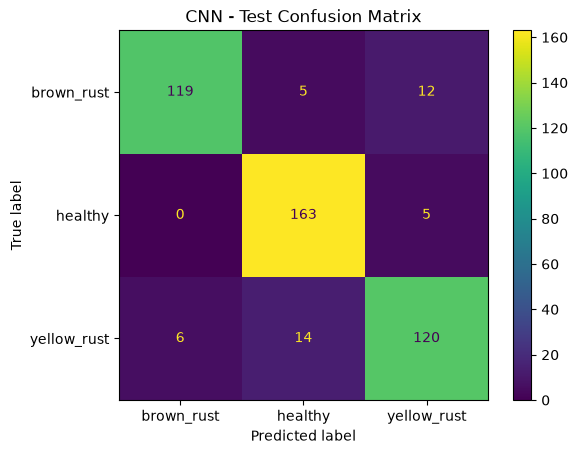

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_true, y_test_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot()

plt.title("CNN - Test Confusion Matrix")
plt.show()

In [26]:
model.save("../models/best_cnn.keras")